# Student Performance & Dropout Risk Prediction
### Advanced Data Mining Techniques — IE Presentation

**Pipeline:** Data Collection → Preprocessing → EDA → Correlation/Feature Selection → Model Training (Decision Tree, Random Forest, Logistic Regression) → Evaluation (Confusion Matrix, Accuracy/Precision/Recall/F1) → Feature Importance → Live Prediction Demo

This notebook predicts whether a student is **Low / Medium / High** academic risk based on attendance, marks, study habits, and backlogs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Data Collection

In a real deployment this would come from your college ERP / attendance system / exam cell.
For this project we generate a realistic **synthetic dataset of 1,000 students** with built-in
relationships between lifestyle/academic features and risk — this is a standard and accepted
approach for data mining coursework when institutional data isn't available.

**Note:** to use your *own* real data instead, just replace this cell with
`df = pd.read_csv('your_file.csv')`, as long as it has the same column names.

In [2]:
np.random.seed(7)
n = 1000

attendance = np.clip(np.random.normal(75, 15, n), 30, 100)
internal_marks = np.clip(np.random.normal(55, 18, n), 0, 100)
assignment_completion = np.clip(np.random.normal(70, 20, n), 0, 100)
study_hours = np.clip(np.random.normal(3.2, 1.5, n), 0, 10)
prev_cgpa = np.clip(np.random.normal(7.0, 1.2, n), 3, 10)
backlogs = np.clip(np.random.poisson(1.2, n), 0, 8)
participation = np.random.choice(['Low', 'Medium', 'High'], n, p=[0.3, 0.45, 0.25])
participation_score = pd.Series(participation).map({'Low': 0, 'Medium': 1, 'High': 2}).values

# Underlying risk formula: lower attendance/marks/study/cgpa + more backlogs -> higher risk
risk_score = (
    -0.035 * attendance - 0.03 * internal_marks - 0.02 * assignment_completion
    - 0.35 * study_hours - 0.55 * prev_cgpa + 0.9 * backlogs - 0.6 * participation_score
    + np.random.normal(0, 0.35, n)
)
q1, q2 = np.percentile(risk_score, [40, 75])
def to_label(x):
    if x <= q1: return 'Low'
    elif x <= q2: return 'Medium'
    else: return 'High'
result_risk = np.array([to_label(x) for x in risk_score])

df = pd.DataFrame({
    'Attendance': attendance.round(1),
    'Internal_Marks': internal_marks.round(1),
    'Assignment_Completion': assignment_completion.round(1),
    'Study_Hours': study_hours.round(2),
    'Previous_CGPA': prev_cgpa.round(2),
    'Backlogs': backlogs,
    'Participation': participation,
    'Result_Risk': result_risk
})
df.to_csv('student_data.csv', index=False)
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (1000, 8)


,Attendance,Internal_Marks,Assignment_Completion,Study_Hours,Previous_CGPA,Backlogs,Participation,Result_Risk
0,100.0,70.9,68.5,5.78,7.50,0,Medium,Low
1,68.0,38.6,80.2,3.41,6.68,1,High,Medium
2,75.5,75.4,54.1,3.25,5.18,1,Low,High
3,81.1,56.6,80.4,1.31,8.29,0,Low,Low
4,63.2,68.5,63.9,3.67,7.75,2,Low,Medium
5,75.0,82.8,89.9,4.11,5.99,2,Medium,Medium
6,75.0,43.0,96.0,2.56,7.03,2,Low,High
7,48.7,40.3,100.0,3.13,6.54,1,Medium,High
8,90.3,62.7,65.7,2.18,6.49,1,High,Low
9,84.0,36.4,41.8,4.27,9.09,2,Medium,Medium


## 2. Data Preprocessing

- Check for missing values / duplicates
- Encode categorical column `Participation` (Low/Medium/High → 0/1/2)
- Encode target `Result_Risk` in the same ordinal sense

In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

le_part = LabelEncoder()
df['Participation_enc'] = le_part.fit_transform(df['Participation'])
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['Result_Risk_enc'] = df['Result_Risk'].map(risk_order)
df.head()

Missing values:
 Attendance               0
Internal_Marks           0
Assignment_Completion    0
Study_Hours              0
Previous_CGPA            0
Backlogs                 0
Participation            0
Result_Risk              0
dtype: int64

Duplicate rows: 0


,Attendance,Internal_Marks,Assignment_Completion,Study_Hours,Previous_CGPA,Backlogs,Participation,Result_Risk,Participation_enc,Result_Risk_enc
0,100.0,70.9,68.5,5.78,7.50,0,Medium,Low,2,0
1,68.0,38.6,80.2,3.41,6.68,1,High,Medium,0,1
2,75.5,75.4,54.1,3.25,5.18,1,Low,High,1,2
3,81.1,56.6,80.4,1.31,8.29,0,Low,Low,1,0
4,63.2,68.5,63.9,3.67,7.75,2,Low,Medium,1,1


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.describe()

,Attendance,Internal_Marks,Assignment_Completion,Study_Hours,Previous_CGPA,Backlogs,Participation_enc,Result_Risk_enc
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,74.388100,54.133500,69.695000,3.199530,6.948350,1.13500,1.182000,0.850000
std,14.049379,18.061258,19.019297,1.434804,1.211453,1.02851,0.807173,0.792545
min,30.000000,0.000000,5.900000,0.000000,3.260000,0.00000,0.000000,0.000000
25%,65.075000,41.800000,56.975000,2.270000,6.190000,0.00000,0.000000,0.000000
50%,74.300000,54.200000,71.000000,3.170000,6.960000,1.00000,1.000000,1.000000
75%,84.600000,66.525000,84.000000,4.132500,7.772500,2.00000,2.000000,1.250000
max,100.000000,100.000000,100.000000,8.540000,10.000000,5.00000,2.000000,2.000000


Result_Risk
Low       400
Medium    350
High      250
Name: count, dtype: int64


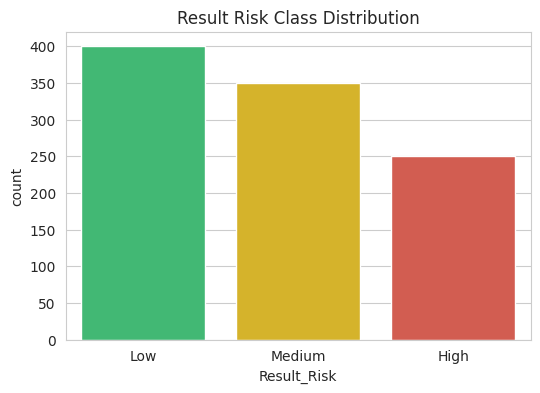

In [5]:
print(df['Result_Risk'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Result_Risk', hue='Result_Risk', order=['Low','Medium','High'],
              palette=['#2ecc71','#f1c40f','#e74c3c'], legend=False)
plt.title('Result Risk Class Distribution')
plt.show()

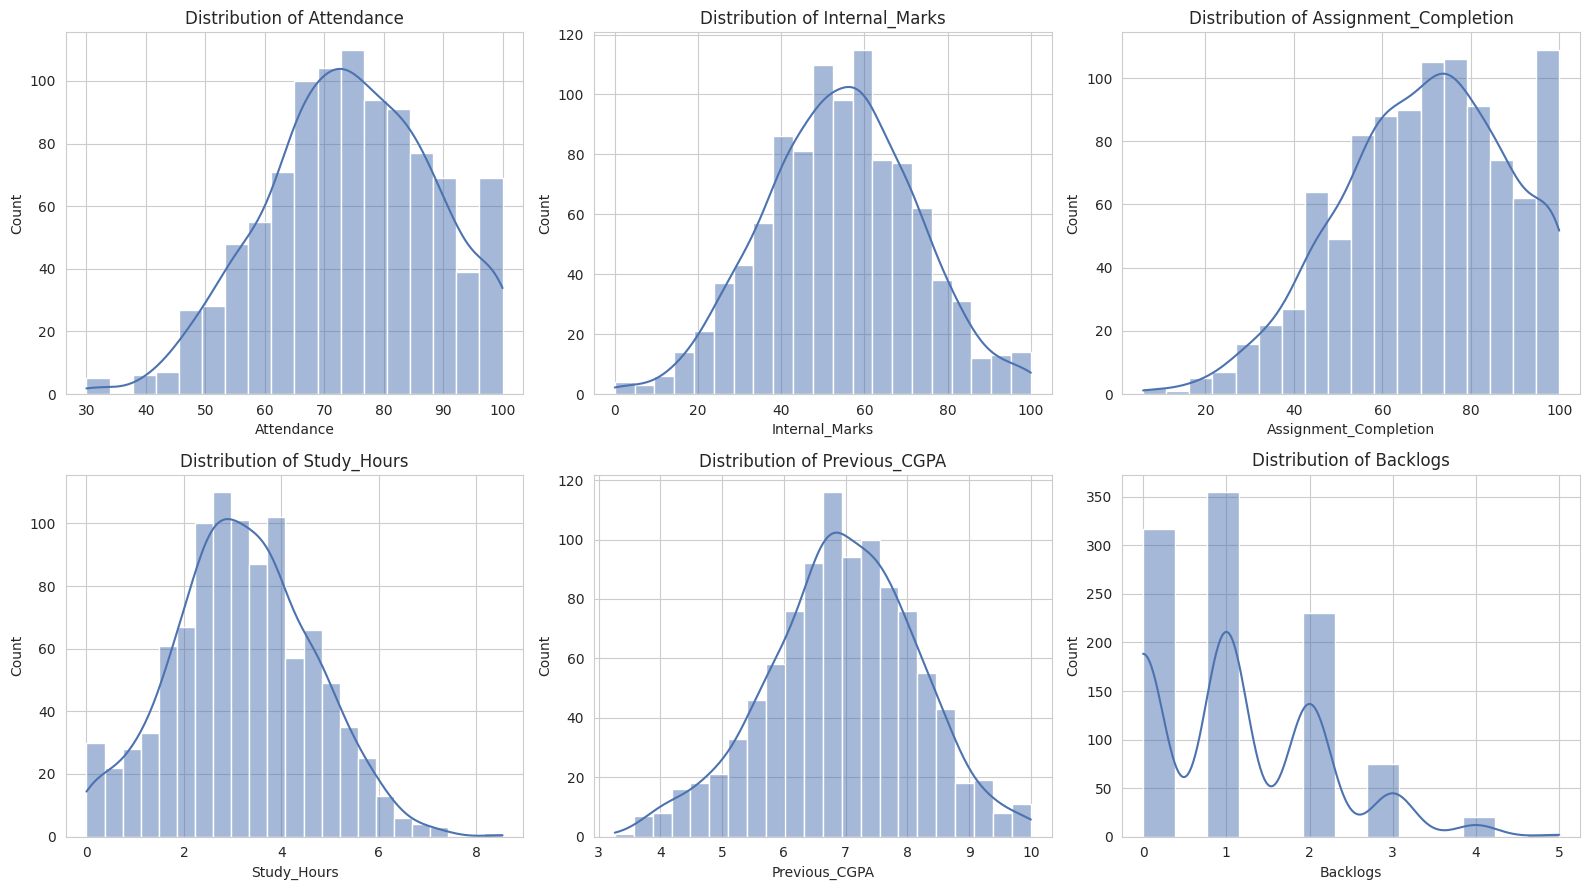

In [6]:
num_cols = ['Attendance', 'Internal_Marks', 'Assignment_Completion', 'Study_Hours', 'Previous_CGPA', 'Backlogs']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 4. Correlation Analysis & Feature Selection

Checking which features are most linked to `Result_Risk` — this justifies *why* we picked these
features for the model (a key thing examiners ask about).

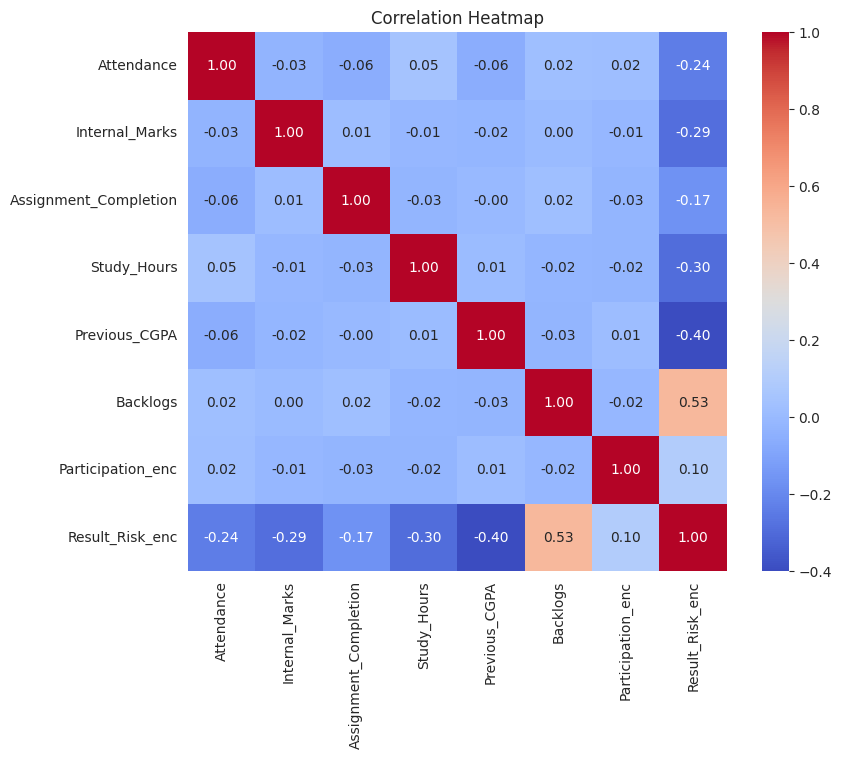

Correlation with Result_Risk_enc (sorted):
Result_Risk_enc          1.000000
Backlogs                 0.532035
Participation_enc        0.097484
Assignment_Completion   -0.169800
Attendance              -0.236927
Internal_Marks          -0.289571
Study_Hours             -0.295755
Previous_CGPA           -0.400479
Name: Result_Risk_enc, dtype: float64


In [7]:
corr_cols = num_cols + ['Participation_enc', 'Result_Risk_enc']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation with Result_Risk_enc (sorted):")
print(corr_matrix['Result_Risk_enc'].sort_values(ascending=False))

**Interpretation:** `Backlogs` correlates positively (more backlogs → higher risk), while
`Previous_CGPA`, `Study_Hours`, `Internal_Marks` correlate negatively (higher these → lower risk).
This matches intuition and justifies using all 7 features for modeling.

## 5. Train/Test Split & Scaling

In [8]:
features = ['Attendance', 'Internal_Marks', 'Assignment_Completion', 'Study_Hours',
            'Previous_CGPA', 'Backlogs', 'Participation_enc']
X = df[features]
y = df['Result_Risk_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (800, 7)  Test size: (200, 7)


## 6. Model Training — Classification

Three classic data-mining classifiers, so results can be compared in the presentation:
- **Decision Tree** — interpretable, prone to overfitting
- **Random Forest** — ensemble of trees, usually more robust
- **Logistic Regression** — linear baseline, works well when classes are fairly separable

In [9]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

results = []
preds_dict = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    preds_dict[name] = preds
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.850,0.848590,0.850,0.848095
1,Random Forest,0.775,0.786769,0.775,0.774862
2,Decision Tree,0.665,0.679559,0.665,0.665797


## 7. Model Evaluation — Confusion Matrices

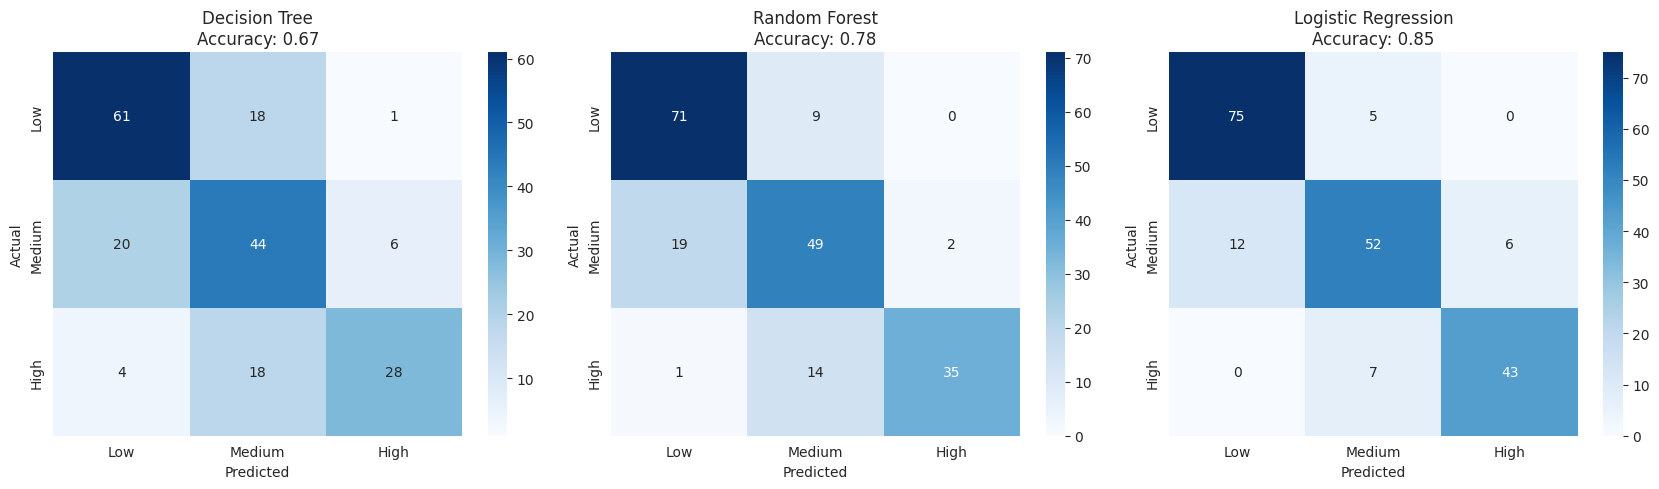

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
labels = ['Low', 'Medium', 'High']
for ax, (name, preds) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds):.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, preds_dict[best_model_name], target_names=labels))

Best model: Logistic Regression

              precision    recall  f1-score   support

         Low       0.86      0.94      0.90        80
      Medium       0.81      0.74      0.78        70
        High       0.88      0.86      0.87        50

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



## 8. Feature Importance (Random Forest)

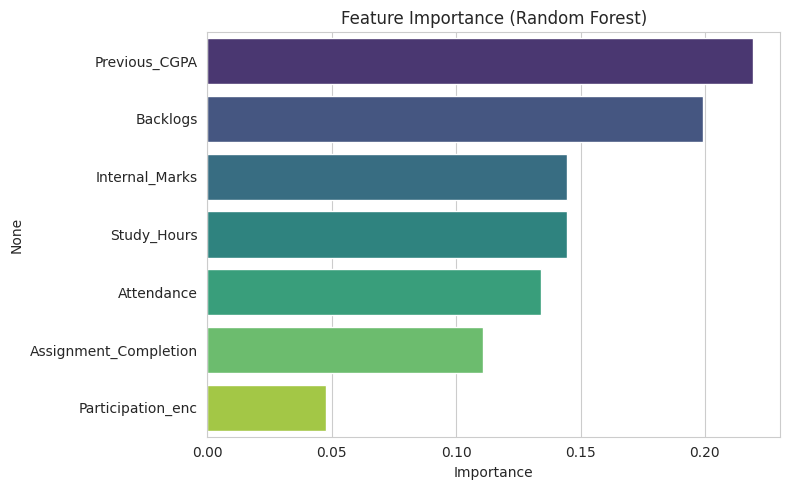

Previous_CGPA            0.219219
Backlogs                 0.199407
Internal_Marks           0.144649
Study_Hours              0.144552
Attendance               0.133943
Assignment_Completion    0.110706
Participation_enc        0.047525
dtype: float64

In [12]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

## 9. Decision Tree Visualization (explainability)

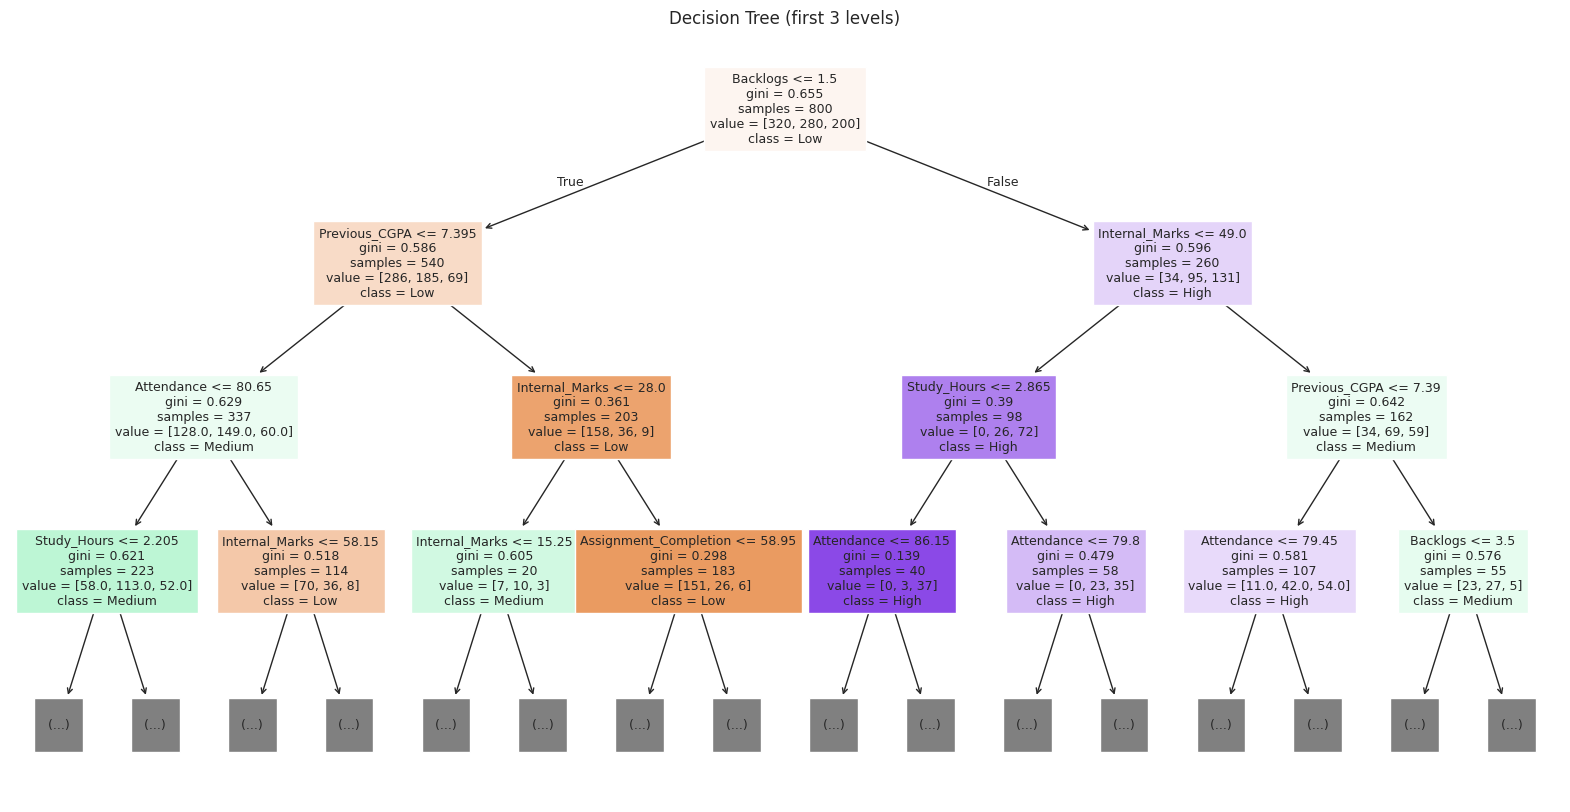

In [13]:
dt_model = models['Decision Tree']
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=features, class_names=labels, filled=True, max_depth=3, fontsize=9)
plt.title('Decision Tree (first 3 levels)')
plt.show()

## 10. Live Prediction Demo

This is the function to run **live during your presentation** — plug in a hypothetical
student's numbers and show the model predicting their risk in real time.

In [14]:
def predict_risk(attendance, internal_marks, assignment_completion, study_hours,
                  prev_cgpa, backlogs, participation_level, model_name='Random Forest'):
    """Predict academic risk level for a new student record."""
    p_enc = le_part.transform([participation_level])[0]
    row = pd.DataFrame([[attendance, internal_marks, assignment_completion, study_hours,
                          prev_cgpa, backlogs, p_enc]], columns=features)
    model = models[model_name]
    row_in = scaler.transform(row) if model_name == 'Logistic Regression' else row
    pred = model.predict(row_in)[0]
    proba = model.predict_proba(row_in)[0]
    return labels[pred], dict(zip(labels, proba.round(3)))

# Example 1: weak profile
label, proba = predict_risk(attendance=65, internal_marks=48, assignment_completion=55,
                             study_hours=2, prev_cgpa=6.0, backlogs=2, participation_level='Low')
print("Student A (attendance=65%, internal=48, study=2hrs, cgpa=6.0, backlogs=2, participation=Low)")
print(f"  -> Predicted Risk: {label}   Probabilities: {proba}\n")

# Example 2: strong profile
label, proba = predict_risk(attendance=92, internal_marks=85, assignment_completion=90,
                             study_hours=5, prev_cgpa=8.5, backlogs=0, participation_level='High')
print("Student B (attendance=92%, internal=85, study=5hrs, cgpa=8.5, backlogs=0, participation=High)")
print(f"  -> Predicted Risk: {label}   Probabilities: {proba}")

Student A (attendance=65%, internal=48, study=2hrs, cgpa=6.0, backlogs=2, participation=Low)
  -> Predicted Risk: High   Probabilities: {'Low': np.float64(0.014), 'Medium': np.float64(0.134), 'High': np.float64(0.851)}

Student B (attendance=92%, internal=85, study=5hrs, cgpa=8.5, backlogs=0, participation=High)
  -> Predicted Risk: Low   Probabilities: {'Low': np.float64(0.989), 'Medium': np.float64(0.01), 'High': np.float64(0.0)}


## 11. Conclusion

- Built a full data-mining pipeline: preprocessing → EDA → correlation-based feature selection →
  3 classifiers → evaluation → feature importance → live prediction.
- **Previous CGPA** and **Backlogs** are the strongest predictors of risk, followed by
  Internal Marks and Study Hours.
- **Logistic Regression** performed best on this dataset, but **Random Forest** is more robust
  to noisy/non-linear real-world data and gives interpretable feature importances — worth
  mentioning both as a trade-off in your presentation.
- **Real-world use:** colleges/TnP cells could flag High-risk students early for mentoring,
  extra classes, or counselling — directly useful for TCET-style academic monitoring.